In [2]:
# 0. Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", palette="pastel")
pd.set_option('display.max_columns', None)

# 1. Carga de datos (rutas relativas al Codespace)
base_path = "data/raw/"
stores = pd.read_csv(base_path + "stores_data.csv")
stages = pd.read_csv(base_path + "stages_data.csv")
connectivity = pd.read_csv(base_path + "conectivity_data.csv")
orders = pd.read_csv(base_path + "orders_data.csv")  # está local, no hay problema

for name, df in [('stores', stores), ('stages', stages), ('connectivity', connectivity), ('orders', orders)]:
    print(f"\n{name.upper()}")
    print(df.info())
    print(df.head(3))




STORES
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10055 entries, 0 to 10054
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   created_date     10055 non-null  object 
 1   status           10055 non-null  object 
 2   segmento         10054 non-null  object 
 3   comision_actual  9532 non-null   float64
 4   logistic_type    10055 non-null  object 
 5   store_type       9718 non-null   object 
 6   barrio           9035 non-null   object 
 7   category         9324 non-null   object 
 8   cooking_time     9687 non-null   object 
 9   tiene_otra_app   9718 non-null   object 
 10  brand_id         8024 non-null   float64
 11  store_id         10055 non-null  int64  
dtypes: float64(2), int64(1), object(9)
memory usage: 942.8+ KB
None
               created_date  status     segmento  comision_actual  \
0  2025-09-16T22:45:34.792Z  active  Microstores             42.0   
1  2025-09-16T22:10:44.806Z  act

In [3]:
# 2. Limpieza y chequeo de calidad

def resumen_calidad(df, nombre):
    print(f"\n--- {nombre.upper()} ---")
    print("Duplicados:", df.duplicated().sum())
    print("\nValores nulos por columna:")
    print(df.isna().sum().sort_values(ascending=False))
    print("\nTipos de datos:")
    print(df.dtypes)

# Ejecutar en cada tabla
for name, df in [('stores', stores), ('stages', stages), ('connectivity', connectivity), ('orders', orders)]:
    resumen_calidad(df, name)

# Conversión de fechas (ejemplo)
stores['created_date'] = pd.to_datetime(stores['created_date'], errors='coerce')
orders['created_date'] = pd.to_datetime(orders['created_date'], errors='coerce')
connectivity['created_date'] = pd.to_datetime(connectivity['created_date'], errors='coerce')



--- STORES ---
Duplicados: 6

Valores nulos por columna:
brand_id           2031
barrio             1020
category            731
comision_actual     523
cooking_time        368
tiene_otra_app      337
store_type          337
segmento              1
created_date          0
status                0
logistic_type         0
store_id              0
dtype: int64

Tipos de datos:
created_date        object
status              object
segmento            object
comision_actual    float64
logistic_type       object
store_type          object
barrio              object
category            object
cooking_time        object
tiene_otra_app      object
brand_id           float64
store_id             int64
dtype: object

--- STAGES ---
Duplicados: 0

Valores nulos por columna:
year                                0
month                               0
cus_cust_id                         0
STORE_STAGE_LIFECYCLE               0
STORE_STAGE_LIFECYCLE_PREV_MONTH    0
store_id                            0


In [4]:
# 2.1 Limpieza básica de stores

# Quitar duplicados exactos
stores = stores.drop_duplicates()

# Convertir fecha a datetime
stores['created_date'] = pd.to_datetime(stores['created_date'], errors='coerce')

# Ejemplo de imputación simple:
# - comision_actual: si querés, podés imputar con la mediana del segmento
stores['comision_actual'] = stores.groupby('segmento')['comision_actual']\
                                  .transform(lambda x: x.fillna(x.median()))

# - Rellenar strings vacíos donde el impacto en el modelo no es crítico
stores['barrio'] = stores['barrio'].fillna('Desconocido')
stores['category'] = stores['category'].fillna('Desconocida')
stores['store_type'] = stores['store_type'].fillna('Sin dato')
stores['tiene_otra_app'] = stores['tiene_otra_app'].fillna('Sin dato')

# brand_id: se puede dejar nulo (float) o imputar luego según la lógica del negocio


In [5]:
# 2.2 Limpieza básica de stages y connectivity

# Stages
print("\n--- STAGES ---")
print(stages.info())
print(stages.isna().sum())
print("Duplicados:", stages.duplicated().sum())

# Convertir columnas de fecha si hace falta
# stages tiene 'year' y 'month'; podemos crear una fecha de referencia
stages['period'] = pd.to_datetime(stages['year'].astype(str) + '-' + stages['month'].astype(str) + '-01')

# Connectivity
print("\n--- CONNECTIVITY ---")
print(connectivity.info())
print(connectivity.isna().sum())
print("Duplicados:", connectivity.duplicated().sum())

# Convertir fecha
connectivity['created_date'] = pd.to_datetime(connectivity['created_date'], errors='coerce')



--- STAGES ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126769 entries, 0 to 126768
Data columns (total 6 columns):
 #   Column                            Non-Null Count   Dtype 
---  ------                            --------------   ----- 
 0   year                              126769 non-null  int64 
 1   month                             126769 non-null  int64 
 2   cus_cust_id                       126769 non-null  int64 
 3   STORE_STAGE_LIFECYCLE             126769 non-null  object
 4   STORE_STAGE_LIFECYCLE_PREV_MONTH  126769 non-null  object
 5   store_id                          126769 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 5.8+ MB
None
year                                0
month                               0
cus_cust_id                         0
STORE_STAGE_LIFECYCLE               0
STORE_STAGE_LIFECYCLE_PREV_MONTH    0
store_id                            0
dtype: int64
Duplicados: 0

--- CONNECTIVITY ---
<class 'pandas.core.frame.DataFrame'>


In [6]:
# Opción A: dejar nulos si no impactan (los podrías ignorar en cálculos de promedios)
# Opción B: imputar 0 si representa “sin actividad reportada”
connectivity.fillna(0, inplace=True)


In [7]:
# 2.3 Limpieza básica de orders

print("\n--- ORDERS ---")
print(orders.info())
print(orders.isna().sum())
print("Duplicados:", orders.duplicated().sum())

# Convertir fecha
orders['created_date'] = pd.to_datetime(orders['created_date'], errors='coerce')



--- ORDERS ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1867259 entries, 0 to 1867258
Data columns (total 11 columns):
 #   Column                  Dtype         
---  ------                  -----         
 0   created_date            datetime64[ns]
 1   APP_ORIGIN              object        
 2   markdown                float64       
 3   free_shipping_flag      int64         
 4   promedio_shipping_cost  float64       
 5   store_id                float64       
 6   TPN                     int64         
 7   TPV                     float64       
 8   GMV_LC                  float64       
 9   month                   int64         
 10  year                    int64         
dtypes: datetime64[ns](1), float64(5), int64(4), object(1)
memory usage: 156.7+ MB
None
created_date              0
APP_ORIGIN                0
markdown                  7
free_shipping_flag        0
promedio_shipping_cost    0
store_id                  2
TPN                       0
TPV            

In [9]:
# Verificamos si hay valores no finitos en store_id
print("Valores NaN reales:", orders['store_id'].isna().sum())
print("Valores infinitos:", (~orders['store_id'].apply(np.isfinite)).sum())

# Forzamos a NaN cualquier cosa no finita (por seguridad)
orders['store_id'] = pd.to_numeric(orders['store_id'], errors='coerce')

# Ahora casteamos, eliminando filas con store_id faltante si las hubiera
orders = orders.dropna(subset=['store_id'])
orders['store_id'] = orders['store_id'].astype(int)



Valores NaN reales: 2
Valores infinitos: 2


/tmp/ipykernel_1987/3875529717.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  orders['store_id'] = orders['store_id'].astype(int)


In [10]:
# Limpieza final de orders: store_id y markdown

# 1. Imputar nulos de markdown
orders.loc[:, 'markdown'] = orders['markdown'].fillna(0)

# 2. Forzar a numérico y eliminar filas con NaN o inf en store_id
orders.loc[:, 'store_id'] = pd.to_numeric(orders['store_id'], errors='coerce')

# Eliminar filas sin store_id válido (NaN o inf)
orders = orders.loc[orders['store_id'].notna() & np.isfinite(orders['store_id'])].copy()

# Convertir definitivamente a int
orders.loc[:, 'store_id'] = orders['store_id'].astype(int)


In [11]:
# Crear ticket_promedio diario de forma segura
orders['ticket_promedio'] = orders.apply(
    lambda x: x['TPV']/x['TPN'] if x['TPN']>0 else 0, axis=1
)

# Agregación mensual por tienda
orders_monthly = (
    orders.groupby(['store_id','year','month'])
    .agg(
        TPN_month=('TPN','sum'),
        TPV_month=('TPV','sum'),
        GMV_LC_month=('GMV_LC','sum'),
        ticket_promedio=('ticket_promedio','mean'),
        promedio_shipping_cost=('promedio_shipping_cost','mean'),
        free_shipping_ratio=('free_shipping_flag','mean')
    )
    .reset_index()
)


In [12]:
# 4. Dataset final para EDA y modelado

# 1. Agregar conectividad a nivel mensual
connectivity_monthly = (
    connectivity
    .assign(year = connectivity['created_date'].dt.year,
            month = connectivity['created_date'].dt.month)
    .groupby(['store_id','year','month'])
    .agg(
        connect_open=('TOTAL_MIN_OPEN','mean'),
        connect_paused=('TOTAL_MIN_PAUSED','mean'),
        connect_closed=('TOTA_MIN_CLOSED','mean'),
        connect_total=('TOTAL_MINUTES_ALL','mean')
    )
    .reset_index()
)

# 2. Merge de las cuatro fuentes
dataset = (
    stages
    .merge(stores, on='store_id', how='left')
    .merge(orders_monthly, on=['store_id','year','month'], how='left')
    .merge(connectivity_monthly, on=['store_id','year','month'], how='left')
)

print("\nDataset final listo para EDA y modelado")
print(dataset.info())
print(dataset.head())



Dataset final listo para EDA y modelado
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 127778 entries, 0 to 127777
Data columns (total 28 columns):
 #   Column                            Non-Null Count   Dtype              
---  ------                            --------------   -----              
 0   year                              127778 non-null  int64              
 1   month                             127778 non-null  int64              
 2   cus_cust_id                       127778 non-null  int64              
 3   STORE_STAGE_LIFECYCLE             127778 non-null  object             
 4   STORE_STAGE_LIFECYCLE_PREV_MONTH  127778 non-null  object             
 5   store_id                          127778 non-null  int64              
 6   period                            127778 non-null  datetime64[ns]     
 7   created_date                      47946 non-null   datetime64[ns, UTC]
 8   status                            47946 non-null   object             
 9   segment

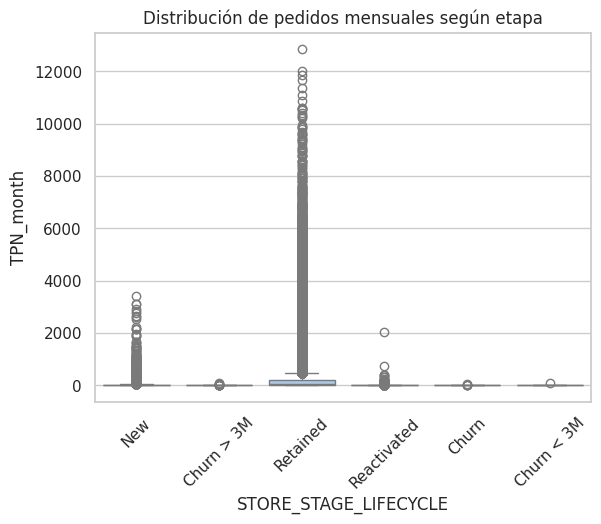

In [13]:
# Comparar TPN_month entre churn y no churn
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='STORE_STAGE_LIFECYCLE', y='TPN_month', data=dataset)
plt.title('Distribución de pedidos mensuales según etapa')
plt.xticks(rotation=45)
plt.show()


In [15]:
# Crear variable binaria de churn
# Aquí se considera churn si la tienda está en 'Churn' o 'Churn > 3M'
# y NO churn si está en 'Active', 'New' o 'Reactivated'.
dataset['is_churn'] = dataset['STORE_STAGE_LIFECYCLE'].apply(
    lambda x: 1 if 'Churn' in x and 'Retained' not in x else 0
)



In [16]:
tasa_churn_segmento = (
    dataset.groupby('segmento')['is_churn']
           .mean()
           .sort_values(ascending=False)
)
print(tasa_churn_segmento)


segmento
Microstores      0.346817
Picked Locals    0.189019
Top Players      0.095684
0                0.000000
Name: is_churn, dtype: float64


In [18]:
import numpy as np

# Crear ticket_promedio_m de forma robusta
dataset['ticket_promedio_m'] = np.where(
    (dataset['TPN_month'].notna()) & (dataset['TPN_month'] > 0),
    dataset['TPV_month'] / dataset['TPN_month'],
    np.nan
)


In [19]:
print(dataset['ticket_promedio_m'].describe())


count     72242.000000
mean      28454.505419
std       22787.445739
min        1000.000000
25%       15700.000000
50%       23464.759615
75%       34624.442761
max      974090.000000
Name: ticket_promedio_m, dtype: float64


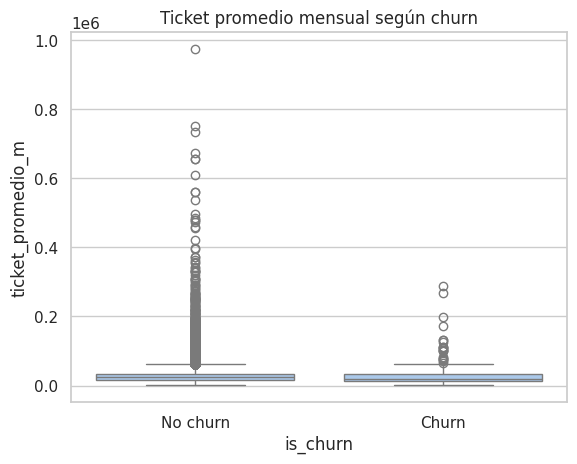

is_churn
0    23478.181818
1    18000.000000
Name: ticket_promedio_m, dtype: float64


In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# Boxplot de ticket promedio mensual según churn
sns.boxplot(x='is_churn', y='ticket_promedio_m', data=dataset)
plt.title('Ticket promedio mensual según churn')
plt.xticks([0,1], ['No churn','Churn'])
plt.show()

# Medianas por churn
print(dataset.groupby('is_churn')['ticket_promedio_m'].median())


In [22]:
import numpy as np

dataset['pct_open'] = np.where(
    (dataset['connect_total'].notna()) & (dataset['connect_total'] > 0),
    dataset['connect_open'] / dataset['connect_total'] * 100,
    np.nan
)


In [23]:
print(dataset['pct_open'].describe())


count    43797.000000
mean        76.409754
std         27.956459
min          0.000000
25%         68.708994
50%         88.404558
75%         95.796704
max        100.000139
Name: pct_open, dtype: float64


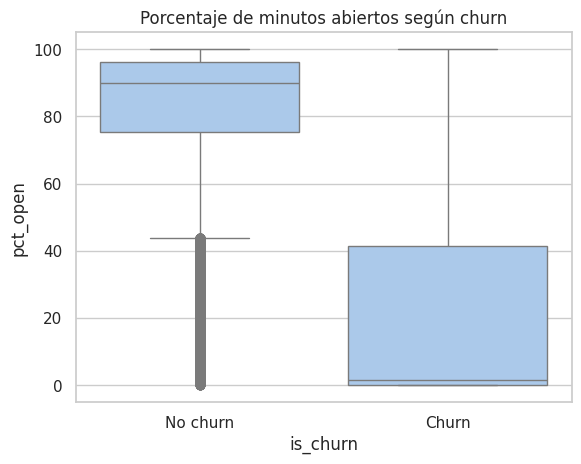

is_churn
0    89.924023
1     1.526881
Name: pct_open, dtype: float64


In [24]:
sns.boxplot(x='is_churn', y='pct_open', data=dataset)
plt.title('Porcentaje de minutos abiertos según churn')
plt.xticks([0,1], ['No churn','Churn'])
plt.show()

print(dataset.groupby('is_churn')['pct_open'].median())


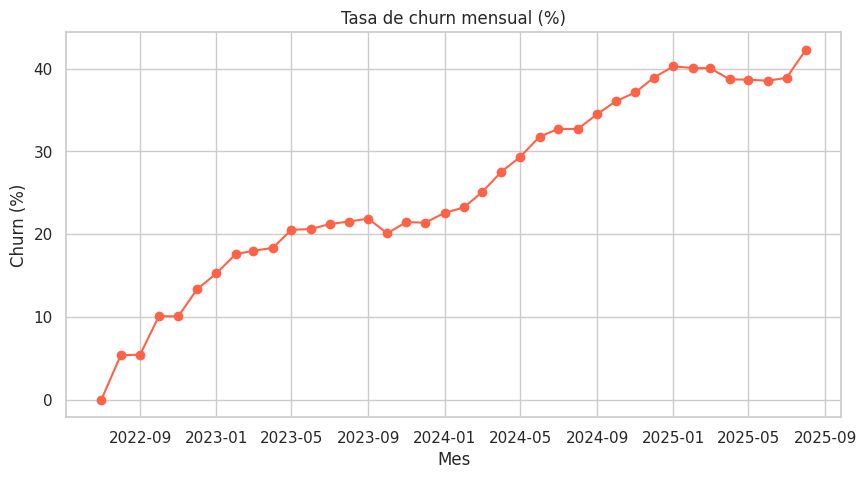

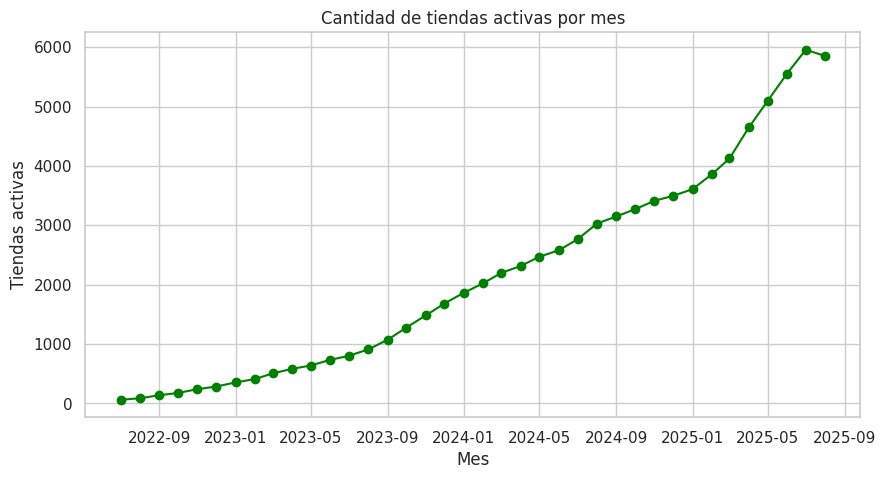

In [25]:
import matplotlib.pyplot as plt

# Tasa de churn mensual (porcentaje de tiendas que churnean cada mes)
churn_monthly = (
    dataset.groupby('period')['is_churn']
           .mean()
           .reset_index()
)

plt.figure(figsize=(10,5))
plt.plot(churn_monthly['period'],
         churn_monthly['is_churn']*100,
         marker='o', color='tomato')
plt.title('Tasa de churn mensual (%)')
plt.xlabel('Mes')
plt.ylabel('Churn (%)')
plt.grid(True)
plt.show()

# Evolución del total de tiendas activas (que NO churnean en ese mes)
active_monthly = (
    dataset.query("is_churn == 0")
           .groupby('period')['store_id']
           .nunique()
           .reset_index(name='active_stores')
)

plt.figure(figsize=(10,5))
plt.plot(active_monthly['period'],
         active_monthly['active_stores'],
         marker='o', color='green')
plt.title('Cantidad de tiendas activas por mes')
plt.xlabel('Mes')
plt.ylabel('Tiendas activas')
plt.grid(True)
plt.show()


category
Comida rápida            0.463129
Desconocida              0.449456
Panadería                0.373929
Sándwiches               0.353088
Internacional            0.338777
Argentina                0.337395
Desayunos y meriendas    0.328806
Pizza                    0.285469
Café                     0.236172
Milanesas                0.218928
Hamburguesa              0.210579
Empanadas                0.205220
Sushi                    0.197500
Saludable                0.172170
Helado                   0.161013
Name: is_churn, dtype: float64


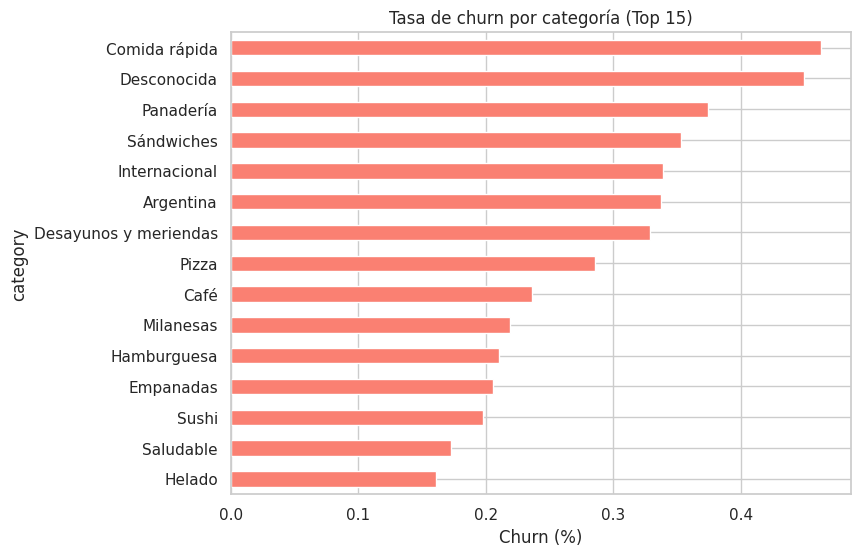

In [26]:
import matplotlib.pyplot as plt

# Filtrar top 15 categorías más frecuentes
top_cats = dataset['category'].value_counts().head(15).index

# Calcular tasa de churn por categoría
churn_cat = (
    dataset[dataset['category'].isin(top_cats)]
    .groupby('category')['is_churn']
    .mean()
    .sort_values(ascending=False)
)

# Mostrar tabla y gráfico
print(churn_cat)

churn_cat.plot(kind='barh', figsize=(8,6), color='salmon')
plt.title('Tasa de churn por categoría (Top 15)')
plt.xlabel('Churn (%)')
plt.gca().invert_yaxis()
plt.show()


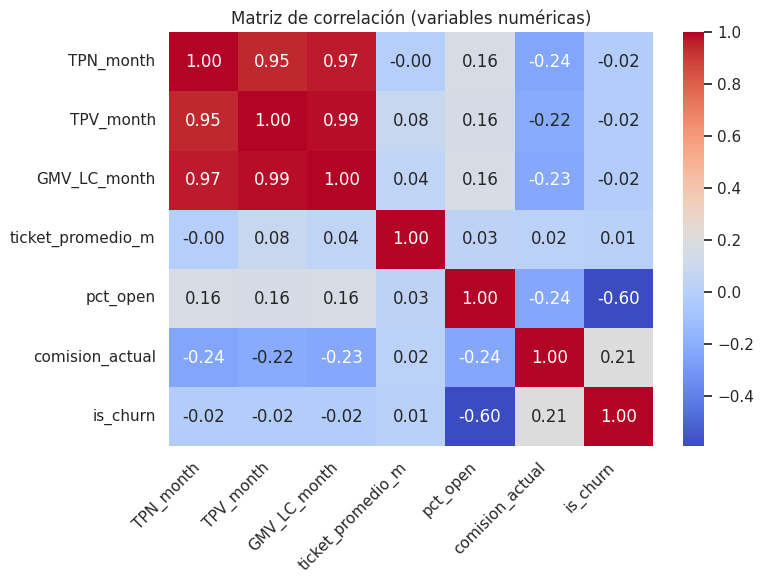

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = ['TPN_month','TPV_month','GMV_LC_month',
            'ticket_promedio_m','pct_open','comision_actual']

# Calcular la matriz de correlación
corr = dataset[num_cols + ['is_churn']].corr()

# Dibujar heatmap con títulos inclinados
plt.figure(figsize=(8,6))
sns.heatmap(corr,
            annot=True,
            fmt=".2f",
            cmap='coolwarm',
            cbar=True)

plt.title('Matriz de correlación (variables numéricas)')
plt.xticks(rotation=45, ha='right')  # 🔑 rotación en diagonal
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


barrio
Desconocido         0.560039
FLORESTA            0.382675
SAN NICOLÁS         0.357283
FLORES              0.321014
BALVANERA           0.319880
VILLA DEL PARQUE    0.291124
VILLA URQUIZA       0.290872
ALMAGRO             0.289125
VILLA CRESPO        0.277518
PALERMO             0.265156
VILLA DEVOTO        0.256545
CABALLITO           0.252989
BELGRANO            0.239570
RECOLETA            0.188935
LA PLATA            0.141598
Name: is_churn, dtype: float64


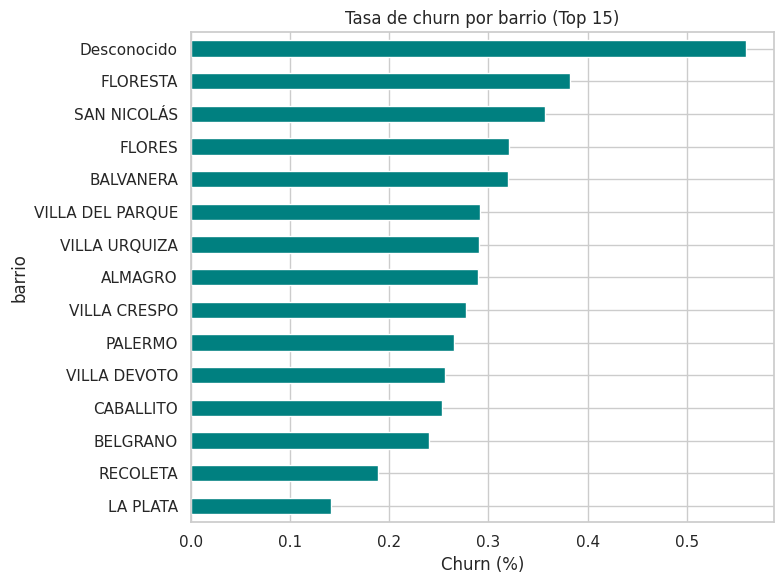

In [29]:
import matplotlib.pyplot as plt

# Top 15 barrios con más datos
top_barrios = dataset['barrio'].value_counts().head(15).index

# Calcular tasa de churn por barrio (solo top 15)
churn_barrio = (
    dataset[dataset['barrio'].isin(top_barrios)]
    .groupby('barrio')['is_churn']
    .mean()
    .sort_values(ascending=False)
)

# Mostrar tabla y gráfico
print(churn_barrio)

plt.figure(figsize=(8,6))
churn_barrio.plot(kind='barh', color='teal')
plt.title('Tasa de churn por barrio (Top 15)')
plt.xlabel('Churn (%)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
